In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Sequential

In [2]:
(X_train,_),(X_test,_) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0 

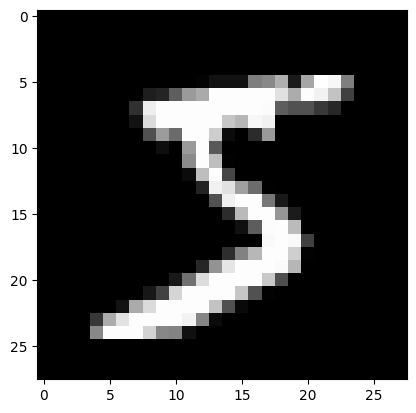

In [3]:
import matplotlib.pyplot as plt 

plt.imshow(X_train[0],cmap='gray')
plt.show()

In [4]:
X_train[0].shape

(28, 28)

In [7]:
X_train = np.reshape(X_train,(-1,28,28,1))

In [15]:
#build encoder 
latend_dim = 2

encoder_input = keras.Input(shape=(28,28,1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation='sigmoid')(x)

z_mean = layers.Dense(latend_dim, name='z_mean')(x)
z_log_var = layers.Dense(latend_dim, name='z_log_var')(x) 

In [20]:
encoder = keras.Model(encoder_input, [z_mean,z_log_var], name='encoder')
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 flatten_2 (Flatten)            (None, 784)          0           ['input_3[0][0]']                
                                                                                                  
 dense_2 (Dense)                (None, 128)          100480      ['flatten_2[0][0]']              
                                                                                                  
 z_mean (Dense)                 (None, 2)            258         ['dense_2[0][0]']                
                                                                                            

In [16]:
def Sampling(args):
    z_mean,z_log_var = args 
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    z = z_mean + tf.exp(0.5*z_log_var) * epsilon 
    return z 
z = layers.Lambda(Sampling)([z_mean,z_log_var])
    

In [18]:
#build decoder 
decoder_input = keras.Input(shape=(latend_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(28*28, activation='sigmoid')(x)
decoder_output = layers.Reshape((28,28,1))(x)

decoder = keras.Model(decoder_input,decoder_output, name='decoder')

In [19]:
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_5 (Dense)             (None, 128)               384       
                                                                 
 dense_6 (Dense)             (None, 784)               101136    
                                                                 
 reshape_1 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
Total params: 101,520
Trainable params: 101,520
Non-trainable params: 0
_________________________________________________________________


In [21]:
output = decoder(z)
vae = keras.Model(encoder_input, output,name='vae')

In [22]:
vae.compile(optimizer='adam', loss='binary_crossentropy')


In [23]:
vae.fit(X_train,X_train,epochs=10,batch_size=10)

Epoch 1/10
6000/6000 [==============================] - 14s 2ms/step - loss: 0.2183
Epoch 2/10
6000/6000 [==============================] - 12s 2ms/step - loss: 0.1985
Epoch 3/10
6000/6000 [==============================] - 12s 2ms/step - loss: 0.1939
Epoch 4/10
6000/6000 [==============================] - 12s 2ms/step - loss: 0.1904
Epoch 5/10
6000/6000 [==============================] - 13s 2ms/step - loss: 0.1882
Epoch 6/10
6000/6000 [==============================] - 14s 2ms/step - loss: 0.1865
Epoch 7/10
6000/6000 [==============================] - 14s 2ms/step - loss: 0.1852
Epoch 8/10
6000/6000 [==============================] - 12s 2ms/step - loss: 0.1841
Epoch 9/10
6000/6000 [==============================] - 11s 2ms/step - loss: 0.1831
Epoch 10/10
6000/6000 [==============================] - 11s 2ms/step - loss: 0.1823
